# Spectral Analysis — Meta-Analysis of Phases 1-10

**Goal**: Systematically analyze all gathered experimental data to understand which spectral features universalize and why.

**Methodology**:
1. **Load Raw Caches**: Aggregate `.pkl` files from Phases 4, 7, 8, 9, and 10.
2. **Unify Granularity**: Convert all samples to a "Statement-Level" representation for RAG, and "Trace-Level" for Reasoning/QA.
3. **Extract Universal Features**: Run the full 12-feature suite on every trace.
4. **Analyze Importance**: Use Random Forest to rank features across domains (Math, GPQA, GSM8K, QA, RAG).
5. **Map Feature Topology**: Visualize the correlation between spectral features.

## Section 1 — Setup

In [1]:
import os, sys, shutil, pickle, torch, numpy as np, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr
from google.colab import drive

drive.mount('/content/drive')

REPO_DIR = '/content/hallucination_detection'
BRANCH   = 'research/feature-expansion'

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {BRANCH} https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull -q')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q scipy seaborn tqdm scikit-learn')

from spectral_utils import (
    extract_all_features, sw_var_peak_with_window, sw_var_peak_adaptive,
    FEAT_NAMES, zscore, boot_auc, nadler_fuse, simple_average_fusion, best_nadler_on,
    segment_by_citations, lciteeval_grounding_label
)

print('spectral_utils imported OK')

Mounted at /content/drive
spectral_utils imported OK


## Section 2 — Data Consolidation

In [2]:
DATA_MAP = {
    'Phase 4/5 (Math)':   ('/content/drive/MyDrive/epr_spectral_phase4', 'Math', 'binary'),
    'Phase 7 (GSM8K)':    ('/content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei', 'GSM8K', 'binary'),
    'Phase 8 (GPQA)':     ('/content/drive/MyDrive/epr_spectral_gpqa_72b', 'GPQA', 'binary'),
    'Phase 9 (QA)':       ('/content/drive/MyDrive/spectral_phase9_cache', 'QA', 'binary'),
    'Phase 10 (RAG)':     ('/content/drive/MyDrive/hallucination_detection/cache/phase10_main/raw', 'RAG', 'statement'),
}

def load_master_dataset():
    all_rows = []
    for phase_name, (base_path, domain, ltype) in DATA_MAP.items():
        if not os.path.exists(base_path):
            print(f"Skipping {phase_name}: Path not found at {base_path}")
            continue
        pkl_files = []
        for root, _, files in os.walk(base_path):
            for f in files:
                if f.endswith('.pkl'): pkl_files.append(os.path.join(root, f))

        for fpath in tqdm(pkl_files, desc=f"Loading {phase_name}"):
            fname = os.path.basename(fpath)
            if 'summary' in fname or 'final_results' in fname: continue
            try:
                with open(fpath, 'rb') as f: data = pickle.load(f)
            except Exception: continue

            # Robustly extract samples from list or dict formats
            if isinstance(data, list):
                samples = data
            elif isinstance(data, dict):
                if 'results' in data: samples = data['results']
                elif 'data' in data: samples = data['data']
                else: samples = list(data.values()) # Handle dict-of-samples (Phases 4/7/8)
            else:
                continue

            # Better model name detection if filename is generic
            parent_dir = os.path.basename(os.path.dirname(fpath))
            model_name = fname.split('__')[0].split('_')[0]
            if model_name.lower() in ['inference', 'cache', 'results', 'trivia'] and parent_dir:
                model_name = parent_dir

            for sample in samples:
                if not isinstance(sample, dict): continue

                src = sample.get('output', sample)
                # Expanded key lookups based on debug findings
                text  = src.get('generated_text', src.get('full_text', src.get('text')))
                ents  = src.get('token_entropies', src.get('all_ents', src.get('all_entropies', src.get('entropies', src.get('ents')))))
                offs  = src.get('token_offsets', src.get('offsets'))
                label = sample.get('is_correct', sample.get('label', sample.get('grounding', sample.get('correct'))))

                # Validation
                if ents is None or len(ents) < 3: continue
                # Phase 10 (RAG) doesn't have a top-level label; others do
                if ltype != 'statement' and label is None: continue

                if ltype == 'statement' and text is not None and offs is not None:
                    if 'row' not in sample: continue
                    try:
                        segments = segment_by_citations(text, offs)
                        for seg in segments:
                            # FIX: Corrected argument order and values for grounding label
                            s_label = lciteeval_grounding_label(seg['citation_ids'], sample['row'])
                            if s_label is None: continue

                            h_slice = ents[seg['token_start']:seg['token_end']]
                            if len(h_slice) < 3: continue

                            feats = extract_all_features(h_slice)
                            if feats:
                                all_rows.append({
                                    'phase': phase_name, 'domain': domain, 'model': model_name,
                                    'label': 1 if s_label == 1 else 0, 'h_trace': h_slice, **feats
                                })
                    except Exception:
                        continue
                else:
                    try:
                        feats = extract_all_features(ents)
                        if feats:
                            all_rows.append({
                                'phase': phase_name, 'domain': domain, 'model': model_name,
                                'label': int(label) if isinstance(label, (int, bool)) else 0,
                                'h_trace': ents, **feats
                            })
                    except Exception:
                        continue
    return pd.DataFrame(all_rows)

df = load_master_dataset()
if not df.empty:
    print(f"Master Dataset created: {len(df)} samples")
    print(df.groupby(['domain', 'phase']).size())
else:
    print("Master Dataset is empty. Check paths and Drive mounting.")

Loading Phase 4/5 (Math):   0%|          | 0/16 [00:00<?, ?it/s]

Loading Phase 7 (GSM8K):   0%|          | 0/3 [00:00<?, ?it/s]

Loading Phase 8 (GPQA):   0%|          | 0/2 [00:00<?, ?it/s]

Loading Phase 9 (QA):   0%|          | 0/4 [00:00<?, ?it/s]

Loading Phase 10 (RAG):   0%|          | 0/16 [00:00<?, ?it/s]

Master Dataset created: 7001 samples
domain  phase           
GPQA    Phase 8 (GPQA)       198
GSM8K   Phase 7 (GSM8K)     1319
Math    Phase 4/5 (Math)    1992
QA      Phase 9 (QA)         763
RAG     Phase 10 (RAG)      2729
dtype: int64


## Section 3 — Meta-Analysis

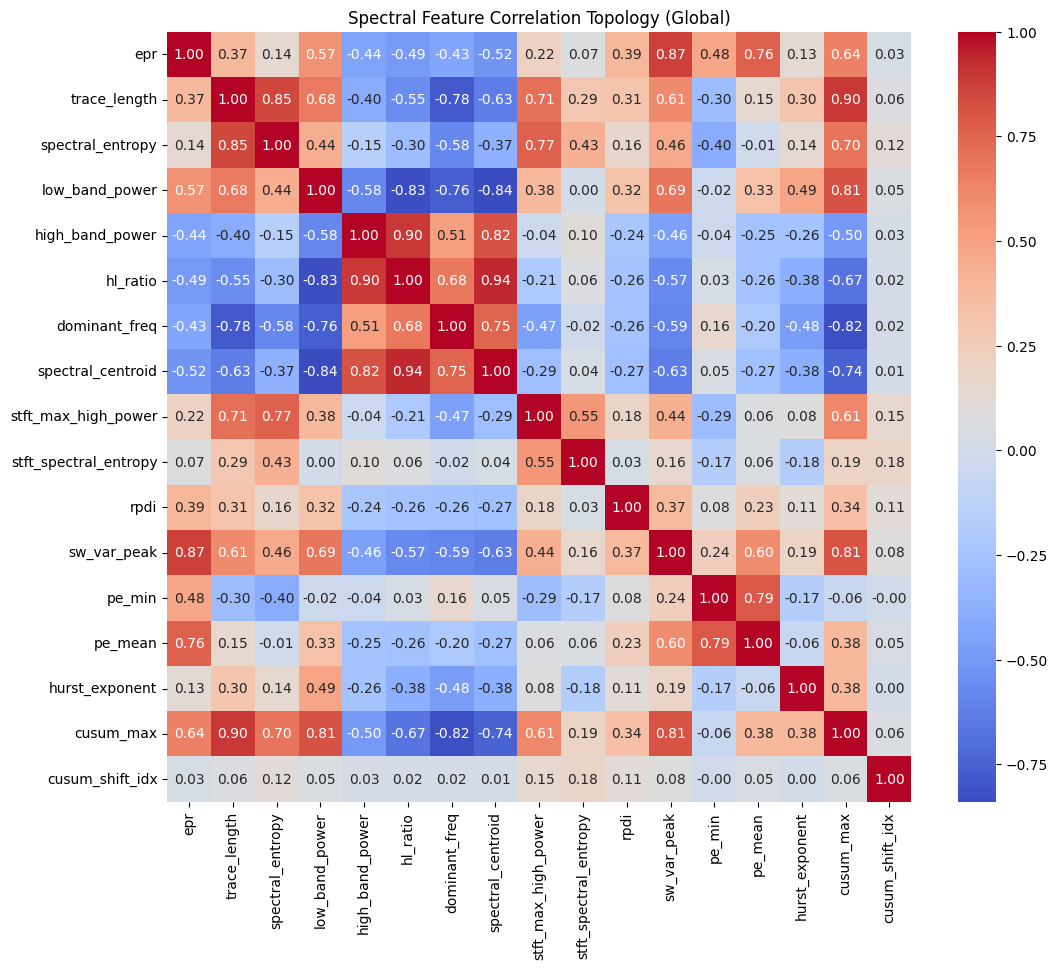

In [3]:
if not df.empty:
    plt.figure(figsize=(12, 10))
    corr = df[FEAT_NAMES].corr(method='spearman')
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Spectral Feature Correlation Topology (Global)")
    plt.show()

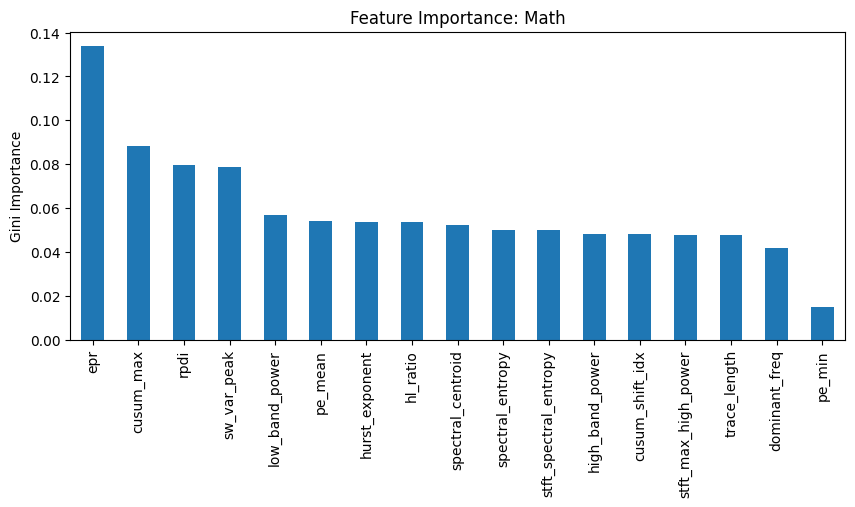

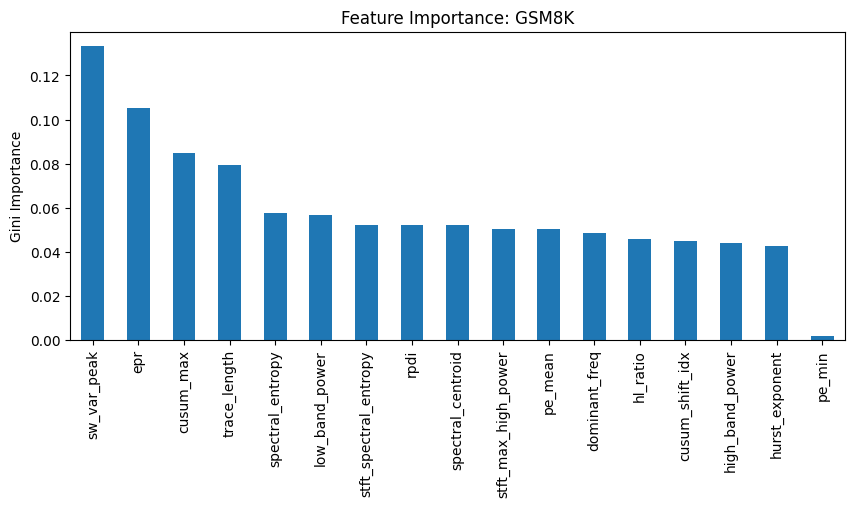

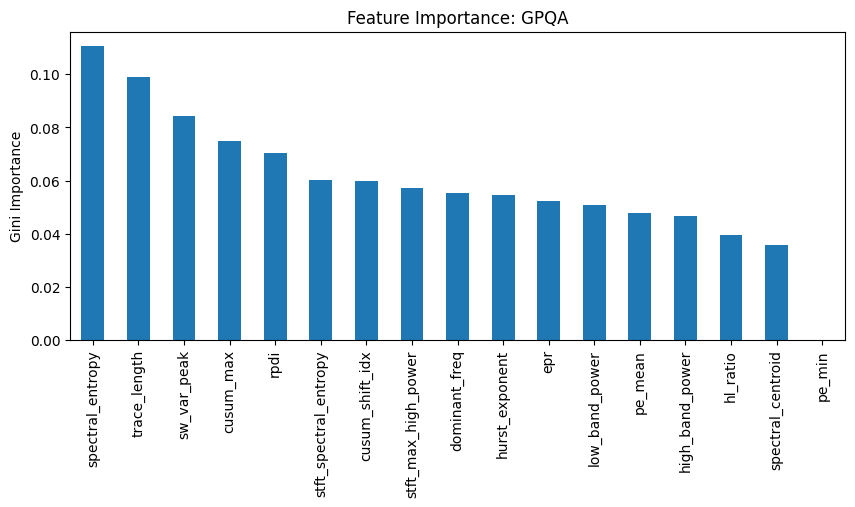

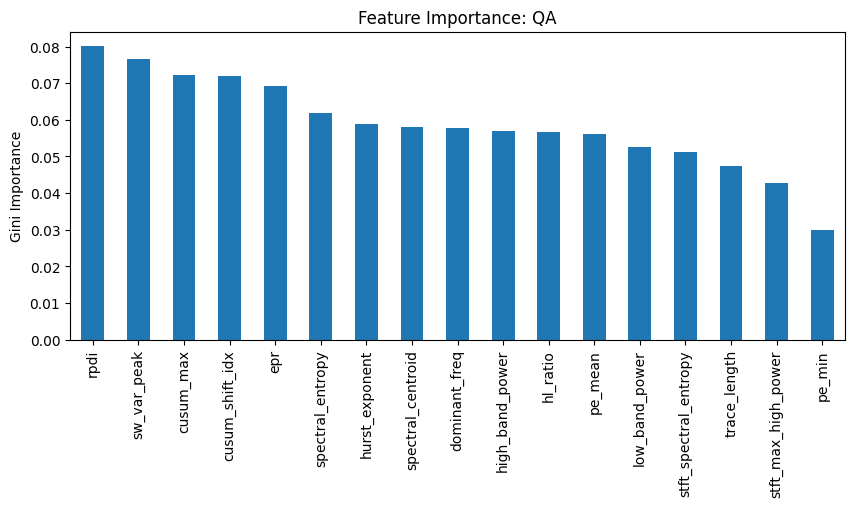

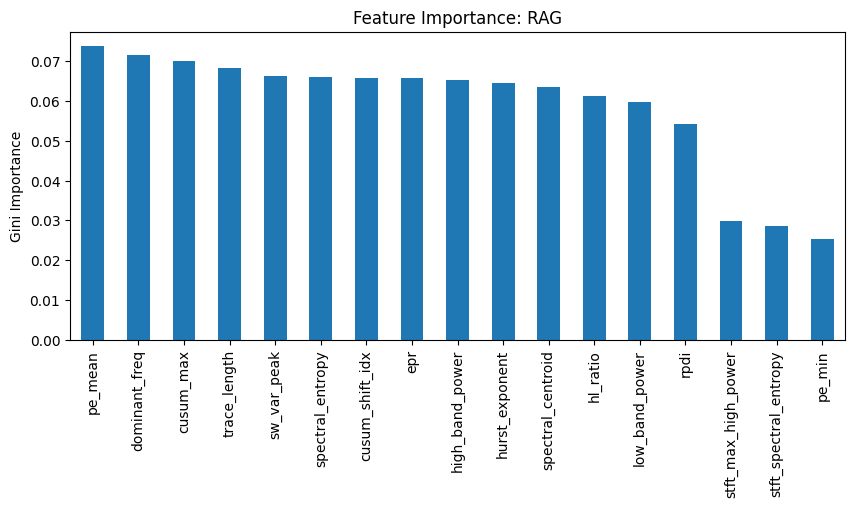

In [4]:
if not df.empty:
    unique_domains = df['domain'].unique()
    domain_importances = {}
    for domain in unique_domains:
        sub_df = df[df['domain'] == domain]
        if len(sub_df['label'].unique()) < 2: continue
        X = sub_df[FEAT_NAMES]; y = sub_df['label']
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X, y)
        domain_importances[domain] = pd.Series(rf.feature_importances_, index=FEAT_NAMES).sort_values(ascending=False)
        plt.figure(figsize=(10, 4))
        domain_importances[domain].plot(kind='bar')
        plt.title(f"Feature Importance: {domain}")
        plt.ylabel("Gini Importance"); plt.show()

In [5]:
if not df.empty and 'domain_importances' in locals():
    rank_df = pd.DataFrame({d: imp.rank(ascending=False) for d, imp in domain_importances.items()})
    rank_df['Average_Rank'] = rank_df.mean(axis=1)
    print("Universal Feature Ranking (Top = Best across all domains):")
    print(rank_df.sort_values('Average_Rank'))

Universal Feature Ranking (Top = Best across all domains):
                       Math  GSM8K  GPQA    QA   RAG  Average_Rank
cusum_max               2.0    3.0   4.0   3.0   3.0           3.0
sw_var_peak             4.0    1.0   3.0   2.0   5.0           3.0
epr                     1.0    2.0  11.0   5.0   8.0           5.4
spectral_entropy       10.0    5.0   1.0   6.0   6.0           5.6
rpdi                    3.0    8.0   5.0   1.0  14.0           6.2
trace_length           15.0    4.0   2.0  15.0   4.0           8.0
pe_mean                 6.0   11.0  13.0  12.0   1.0           8.6
cusum_shift_idx        13.0   14.0   7.0   4.0   7.0           9.0
dominant_freq          16.0   12.0   9.0   9.0   2.0           9.6
low_band_power          5.0    6.0  12.0  13.0  13.0           9.8
hurst_exponent          7.0   16.0  10.0   7.0  10.0          10.0
spectral_centroid       9.0    9.0  16.0   8.0  11.0          10.6
stft_spectral_entropy  11.0    7.0   6.0  14.0  16.0          10.8
hl_

## Section 4 — Spectral Band Optimization

Optimizing bands for Math...


  0%|          | 0/20 [00:00<?, ?it/s]

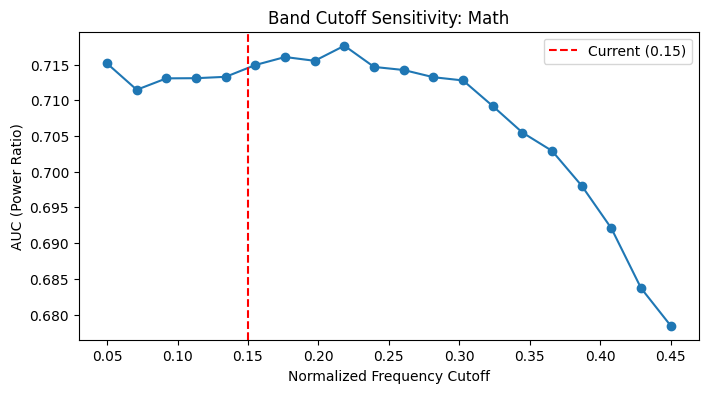

Best Cutoff for Math: 0.218 (AUC: 71.76%)
Optimizing bands for GSM8K...


  0%|          | 0/20 [00:00<?, ?it/s]

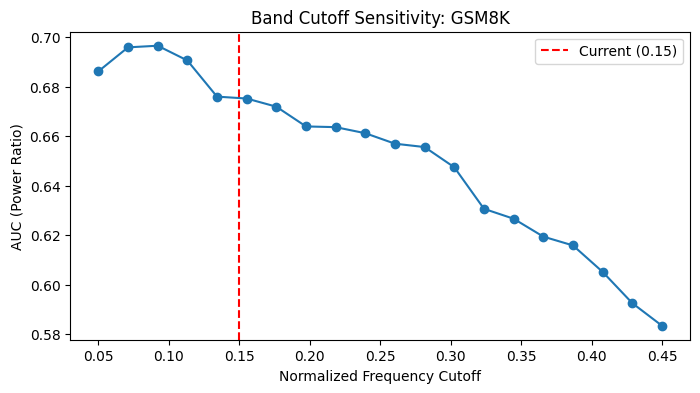

Best Cutoff for GSM8K: 0.092 (AUC: 69.66%)
Optimizing bands for GPQA...


  0%|          | 0/20 [00:00<?, ?it/s]

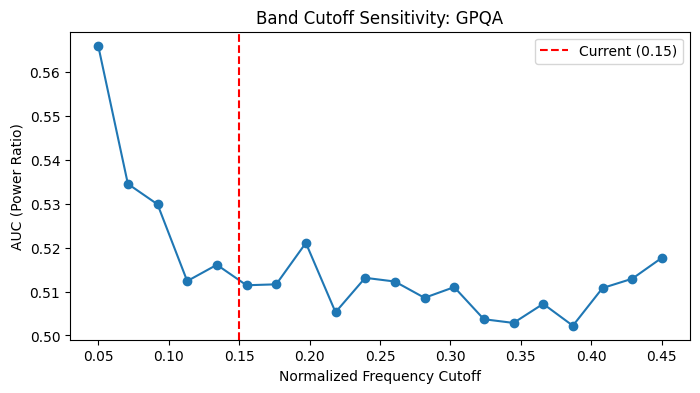

Best Cutoff for GPQA: 0.050 (AUC: 56.60%)
Optimizing bands for QA...


  0%|          | 0/20 [00:00<?, ?it/s]

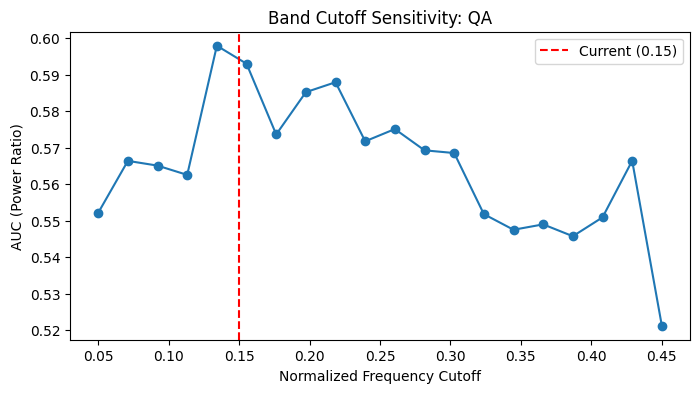

Best Cutoff for QA: 0.134 (AUC: 59.80%)
Optimizing bands for RAG...


  0%|          | 0/20 [00:00<?, ?it/s]

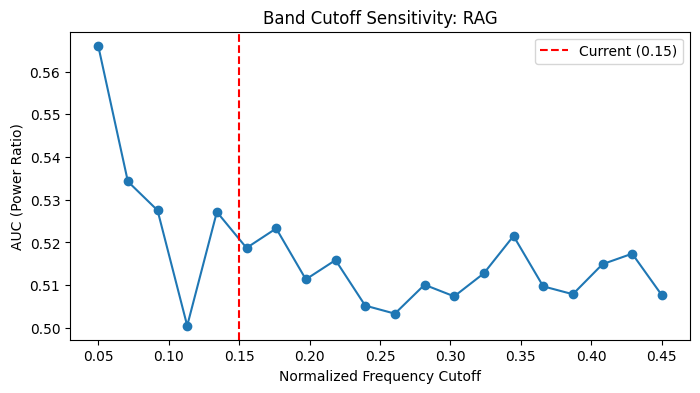

Best Cutoff for RAG: 0.050 (AUC: 56.61%)


In [6]:
def compute_band_ratio(ents, cutoff):
    e = np.array(ents, dtype=float); N = len(e)
    if N < 8: return 0.5
    e_ac = e - e.mean()
    fft_vals = np.fft.rfft(e_ac)
    psd = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(N)
    low_power = psd[freqs <= cutoff].sum()
    high_power = psd[freqs > cutoff].sum()
    return low_power / (high_power + 1e-12)

def optimize_bands_real(sub_df, domain_name):
    cutoffs = np.linspace(0.05, 0.45, 20)
    aucs = []
    print(f"Optimizing bands for {domain_name}...")
    for c in tqdm(cutoffs):
        scores = [compute_band_ratio(h, c) for h in sub_df['h_trace']]
        a = roc_auc_score(sub_df['label'], scores)
        aucs.append(max(a, 1-a))
    plt.figure(figsize=(8, 4))
    plt.plot(cutoffs, aucs, marker='o')
    plt.axvline(0.15, color='red', linestyle='--', label='Current (0.15)')
    plt.title(f"Band Cutoff Sensitivity: {domain_name}")
    plt.xlabel("Normalized Frequency Cutoff"); plt.ylabel("AUC (Power Ratio)")
    plt.legend(); plt.show()
    return cutoffs[np.argmax(aucs)], np.max(aucs)

if not df.empty:
    for domain in df['domain'].unique():
        sub = df[df['domain']==domain]
        if len(sub['label'].unique()) < 2: continue
        best_c, best_a = optimize_bands_real(sub, domain)
        print(f"Best Cutoff for {domain}: {best_c:.3f} (AUC: {best_a:.2%})")

## Section 5 — Multi-Parameter Sensitivity Analysis

Window sweep Math:   0%|          | 0/7 [00:00<?, ?it/s]

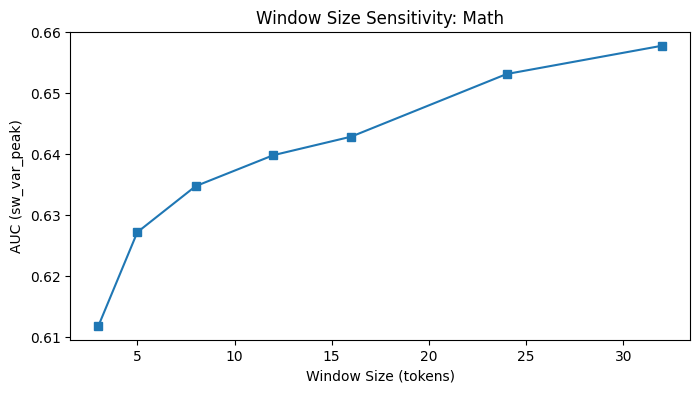

Window sweep GSM8K:   0%|          | 0/7 [00:00<?, ?it/s]

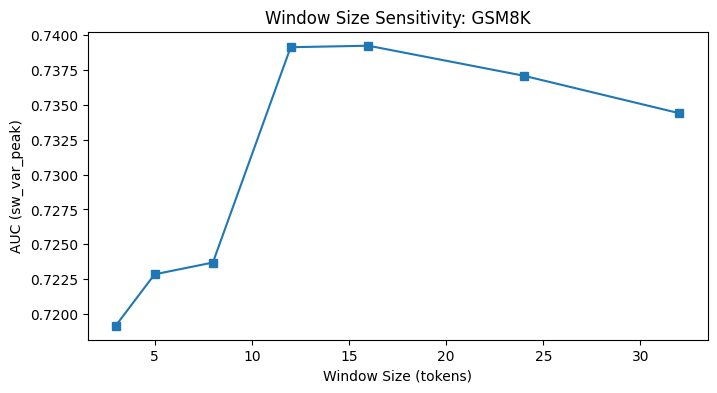

Window sweep GPQA:   0%|          | 0/7 [00:00<?, ?it/s]

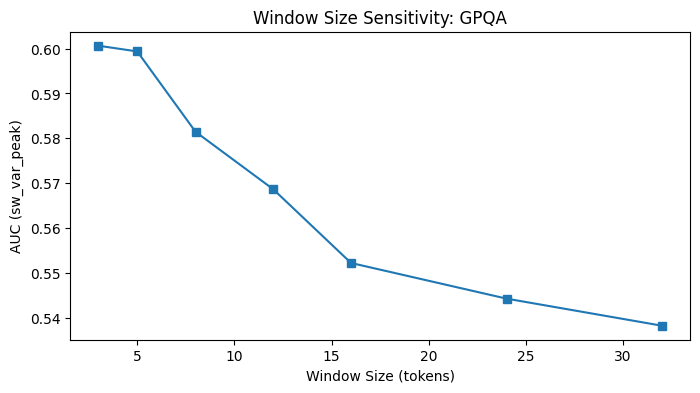

Window sweep QA:   0%|          | 0/7 [00:00<?, ?it/s]

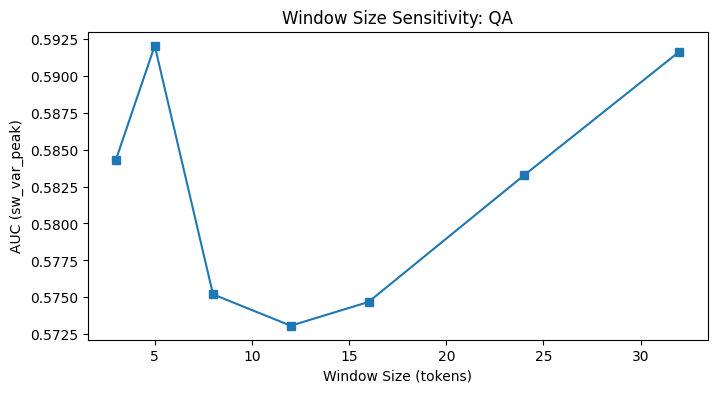

Window sweep RAG:   0%|          | 0/7 [00:00<?, ?it/s]

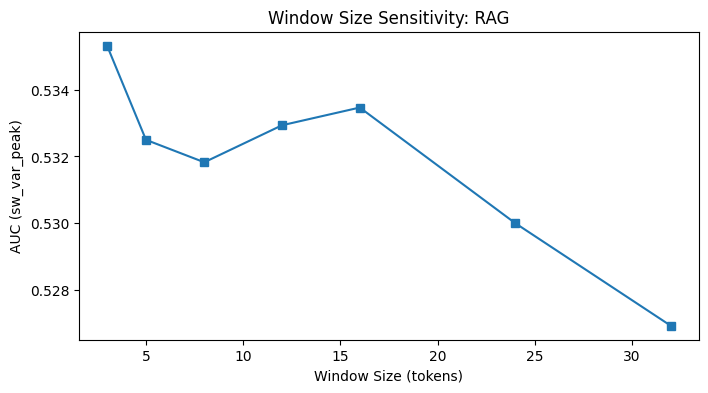

In [7]:
def sweep_window_size(sub_df, domain):
    windows = [3, 5, 8, 12, 16, 24, 32]
    aucs = []
    for w in tqdm(windows, desc=f"Window sweep {domain}"):
        scores = [sw_var_peak_with_window(h, w) for h in sub_df['h_trace']]
        a = roc_auc_score(sub_df['label'], scores)
        aucs.append(max(a, 1-a))
    plt.figure(figsize=(8, 4))
    plt.plot(windows, aucs, marker='s')
    plt.title(f"Window Size Sensitivity: {domain}")
    plt.xlabel("Window Size (tokens)"); plt.ylabel("AUC (sw_var_peak)"); plt.show()

if not df.empty:
    for domain in df['domain'].unique():
        sub = df[df['domain']==domain]
        if len(sub['label'].unique()) < 2: continue
        sweep_window_size(sub, domain)

## Section 6 — Strategic Conclusions

In [8]:
print("Meta-Analysis Ready. Results will inform the implementation of Hurst and Wavelet features.")

Meta-Analysis Ready. Results will inform the implementation of Hurst and Wavelet features.
